# Behaviour PLS for ERP data

Here we use a single participant from the "kiloword dataset" ([Dufau et al., 2015](https://doi.org/10.1177/0956797615603934)) to demonstrate how behaviour PLS can be used to measure multivariate associations between ERP data and experimental covariates (in this case, various features of words presented to participants). It is valuable to compare this to the [MNE tutorial analyzing the same data using linear regression](https://mne.tools/stable/auto_examples/stats/sensor_regression.html).

## Loading and inspecting the data

The kiloword dataset ships with MNE and can be loaded as follows:

In [1]:
import mne
from mne.datasets import kiloword

# Load the data
path = kiloword.data_path() / "kword_metadata-epo.fif"
epochs = mne.read_epochs(path)

Reading C:\Users\isaac\mne_data\MNE-kiloword-data\kword_metadata-epo.fif ...
Isotrak not found


C:\Users\isaac\Projects\mne-plsc\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    Found the data of interest:
        t =    -100.00 ...     920.00 ms
        0 CTF compensation matrices available
Adding metadata with 8 columns
960 matching events found
No baseline correction applied
0 projection items activated


The `epochs` variable contains ERP data for a single participant along with metadata with various features of the words presented per trial:

In [2]:
epochs.metadata

,WORD,Concreteness,WordFrequency,OrthographicDistance,NumberOfLetters,BigramFrequency,ConsonantVowelProportion,VisualComplexity
0,film,5.450000,3.189490,1.75,4.0,343.250,0.750,55.783710
1,cent,5.900000,3.700704,1.35,4.0,546.750,0.750,63.141553
2,shot,4.600000,2.858537,1.20,4.0,484.750,0.750,64.600033
3,cold,3.700000,3.454540,1.15,4.0,1095.250,0.750,63.657457
4,main,3.000000,3.539076,1.35,4.0,686.000,0.500,68.945661
...,...,...,...,...,...,...,...,...
955,drudgery,3.473684,1.556303,2.95,8.0,486.125,0.625,69.732357
956,reversal,3.700000,1.991226,2.65,8.0,859.000,0.625,60.545879
957,billiard,5.500000,1.672098,2.90,8.0,528.875,0.625,55.838597
958,adherent,3.450000,0.698970,2.55,8.0,615.625,0.625,68.088112


## Analyzing associations

We will examine associations between ERP data and several features of the words presented. To do so, we can fit a behaviour PLS model using the `metadata` attribute as the design matrix and specifying the column names containing the covariates we want to examine:

In [3]:
import mne_plsc

res = mne_plsc.fit_beh(epochs,
                       design=epochs.metadata,
                       covariates=['Concreteness', 'WordFrequency'],
                       random_state=123)

We can then visualize the latent variables from the resulting model fit. As we can see, the first latent variable is most strongly related to word frequency and the second is most strongly related to concreteness:

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: >, <Axes: xlabel='Time (s)', ylabel='Salience'>],
       dtype=object))

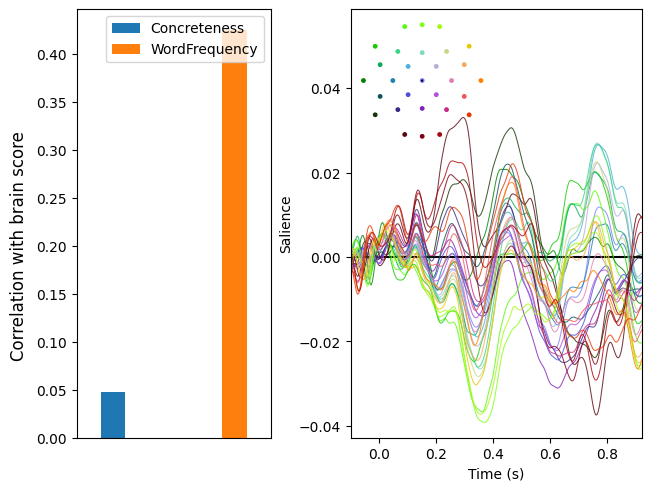

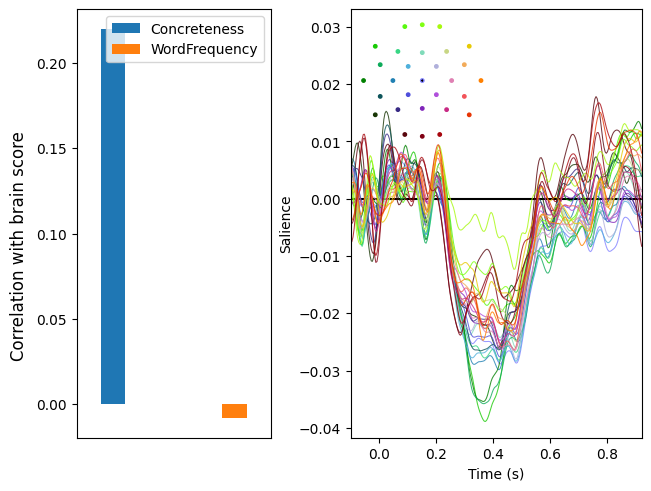

In [4]:
res.plot_lv(0, which='saliences')
res.plot_lv(1, which='saliences')

Note the similarity of the pattern of saliences in the second latent variable to the pattern of regression weights identified by linear regression [here](https://mne.tools/stable/auto_examples/stats/sensor_regression.html).

## Assessing model significance

We can assess the significance of these latent variable pairs via permutation testing. For speed, we will perform only 100 permutations, but for real data it would be advisable to do many more.

Permuting: 100%|█████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.35it/s]


   LV index  singular value  variance explained   p value
0         0        7.973536            0.614902  0.009901
1         1        6.310064            0.385098  0.009901


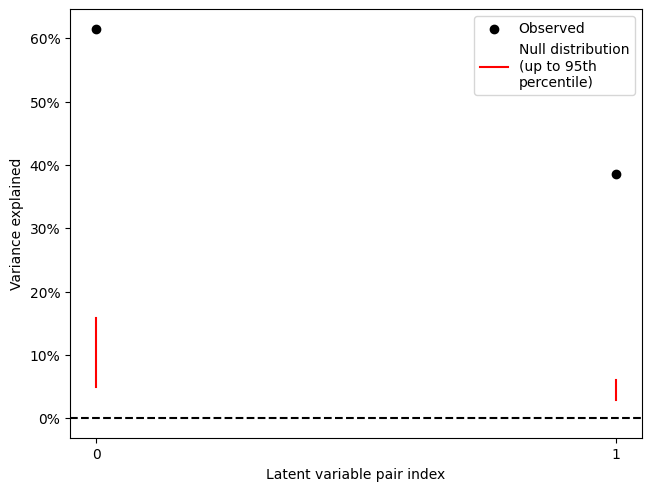

In [5]:
res.permute(100)
print(res.summary())
res.plot_scree()

As we can see, both latent variable pairs are significant.

## Cluster analysis

To evaluate where the brain saliences are particularly strong, we can perform bootstrap resampling followed by clustering:

In [6]:
res.bootstrap(100, return_boot_stat_dist=False)

Resampling: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  6.19it/s]


Before cluster analysis, it is necessary to add an adjacency matrix to the data. In the case of ERP analysis, it generally makes sense to treat all channels as adjacent in order to detect multi-channel patterns. This is the default behaviour of `.add_adjacency()` but can be changed with the `all_channels_adjacent` argument.

In [7]:
res.add_adjacency()
res.cluster(which='z-scores', threshold=2)

Defaulting to all channels adjacent for ERP/ERF analysis
Defaulting to unsigned clustering
Computing clusters for lv_idx 0...
4 clusters
Computing clusters for lv_idx 1...
8 clusters


We will examine the second latent variable pair (lv_idx 1), which is comparable to the example in the MNE documentation. We can examine the distribution of cluster sizes to see that most of the strong saliences (z-score > 2) are part of a single cluster for this latent variable pair:

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

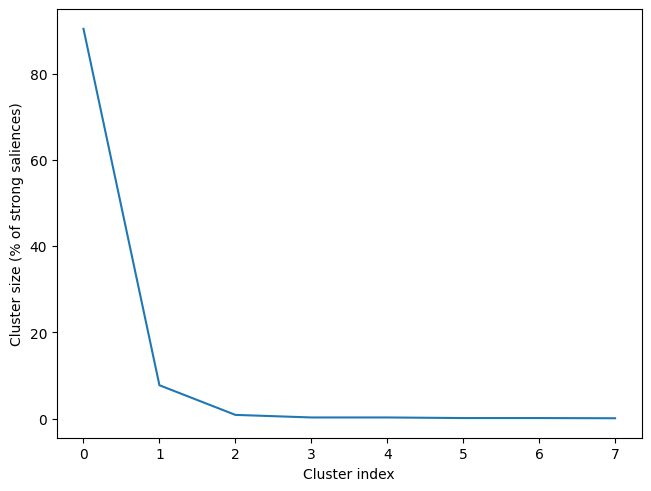

In [8]:
res.plot_cluster_sizes(lv_idx=1)

When we examine this cluster, we can see that it matches very closely the cluster of coefficients from the MNE example that are significant using FDR correction:

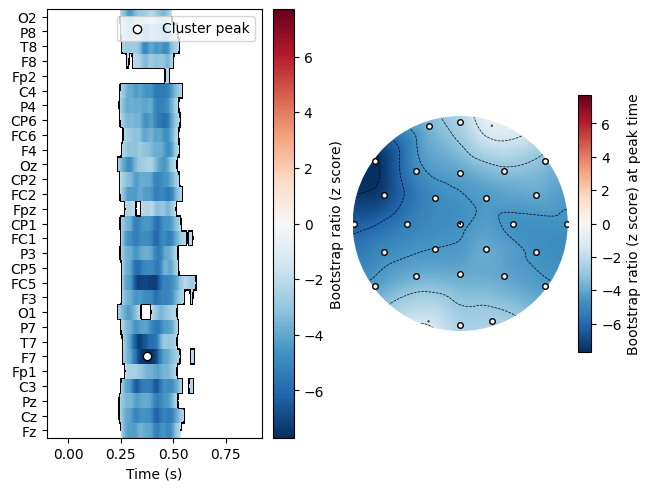

In [9]:
res.plot_cluster(lv_idx=1, cluster_idx=0, plot_type='raster')

It may appear that the plot includes disconnected "islands" of data that are not part of the cluster for FC1, F7, and C3. This is due to an inherent limitation of displaying channel locations along the linear y axis: there is no way to represent that these "islands" are in fact connected to the cluster via channels that are not contiguous along the y axis, but are adjacent in the actual channel montage.